# Apollonian-like Circle Packing

We increase rendering quality with finer grid and many seeded disks.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython import get_ipython

ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(0)
OUT = Path(".")

n = 700
x = np.linspace(-1.2, 1.2, n)
y = np.linspace(-1.2, 1.2, n)
X, Y = np.meshgrid(x, y)
img = np.zeros((n, n))

M = 120
cent = rng.uniform(-1, 1, size=(M, 2))
rad = rng.uniform(0.03, 0.19, size=M)
for c, r in zip(cent, rad):
    d = np.sqrt((X-c[0])**2 + (Y-c[1])**2)
    ring = np.exp(-((d-r)/0.0035)**2)
    img = np.maximum(img, ring)


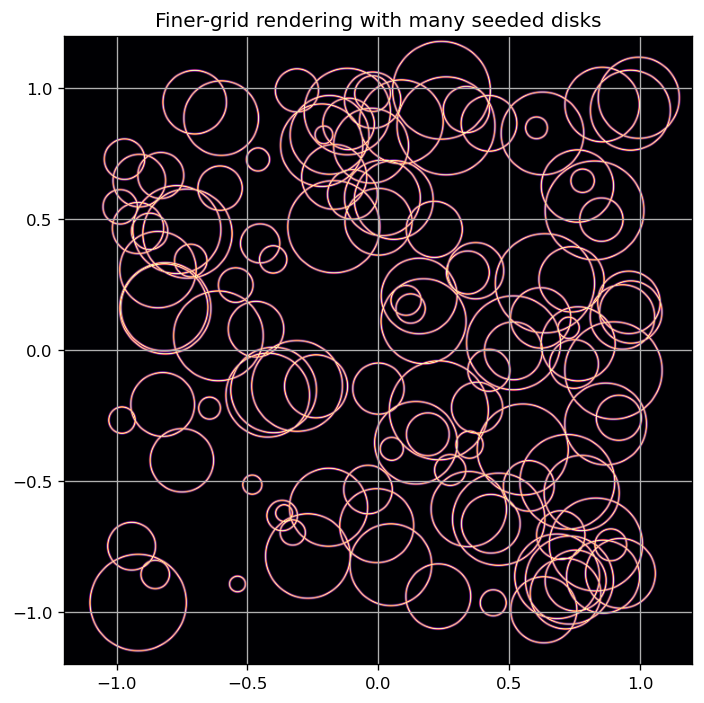

In [2]:
fig, ax = plt.subplots(figsize=(6.8, 6.8))
ax.imshow(img, origin='lower', cmap='magma', extent=[x.min(), x.max(), y.min(), y.max()])
ax.set_title('Finer-grid rendering with many seeded disks')
ax.set_aspect('equal')
fig.savefig(OUT / "snippet.png", bbox_inches="tight")
plt.show()
